# Decision Trees — Exercises 9 & 10
### Breast Cancer Dataset · scikit-learn

| Exercise | Goal |
|----------|------|
| **9** | Depth vs Overfitting — sweep `max_depth` 1–20, compare train vs test accuracy |
| **10** | Explain a single prediction by tracing the exact tree decision path |

**Dataset:** Breast Cancer Wisconsin — 569 samples, 30 features, binary target (`malignant` / `benign`)

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from sklearn.datasets      import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree          import DecisionTreeClassifier, export_text

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
})

SEED   = 42
C_TRAIN = '#4C72B0'   # blue  – train
C_TEST  = '#DD8452'   # orange – test
C_BEST  = '#C44E52'   # red   – best depth
C_TP    = '#55A868'   # green – true positive
C_FP    = '#C44E52'   # red   – false positive

print('Setup complete.')

Setup complete.


## 1 · Load Dataset

In [2]:
bc          = load_breast_cancer()
X, y        = bc.data, bc.target
feat_names  = list(bc.feature_names)
class_names = list(bc.target_names)   # ['malignant', 'benign']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Dataset  : Breast Cancer Wisconsin')
print(f'Samples  : {X.shape[0]}  |  Features: {X.shape[1]}')
print(f'Classes  : {class_names}  (0=malignant, 1=benign)')
print(f'Train    : {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Class balance (test): malignant={sum(y_test==0)}, benign={sum(y_test==1)}')

Dataset  : Breast Cancer Wisconsin
Samples  : 569  |  Features: 30
Classes  : [np.str_('malignant'), np.str_('benign')]  (0=malignant, 1=benign)
Train    : 455 rows  |  Test: 114 rows
Class balance (test): malignant=42, benign=72


---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Exercise 9 — Depth vs Overfitting
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Goal:** Demonstrate overfitting by sweeping `max_depth` from 1 to 20 and comparing train vs test accuracy at every step.

## 9.1 · Tasks 1 & 2 — Sweep max_depth, Record Accuracies

In [3]:
DEPTHS = list(range(1, 21))
records = []

for depth in DEPTHS:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    dt.fit(X_train, y_train)

    train_acc = dt.score(X_train, y_train)
    test_acc  = dt.score(X_test,  y_test)
    n_leaves  = dt.get_n_leaves()
    actual_d  = dt.get_depth()

    records.append({
        'max_depth'   : depth,
        'actual_depth': actual_d,
        'n_leaves'    : n_leaves,
        'train_acc'   : round(train_acc, 4),
        'test_acc'    : round(test_acc,  4),
        'gap'         : round(train_acc - test_acc, 4),
    })

results_ex9 = pd.DataFrame(records)
best_idx    = results_ex9['test_acc'].idxmax()
best_depth  = results_ex9.loc[best_idx, 'max_depth']
best_acc    = results_ex9.loc[best_idx, 'test_acc']

print(f'Best test accuracy : {best_acc:.4f} at max_depth={best_depth}')
print(f'Gap at best depth  : {results_ex9.loc[best_idx, "gap"]:.4f} (train - test)')

Best test accuracy : 0.9386 at max_depth=3
Gap at best depth  : 0.0372 (train - test)


## 9.2 · Task 3 — Depth-Performance Table

In [4]:
def highlight_best(row):
    if row['max_depth'] == best_depth:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    if row['gap'] >= 0.05:
        return ['background-color: #fff3cd'] * len(row)  # warn: high gap
    return [''] * len(row)

results_ex9.style \
    .apply(highlight_best, axis=1) \
    .format({'train_acc': '{:.4f}', 'test_acc': '{:.4f}', 'gap': '{:.4f}'}) \
    .set_caption(
        'Train vs Test Accuracy by max_depth  '
        '(green = best test acc | yellow = train-test gap >= 5%)'
    ) \
    .bar(subset=['gap'], color='#f5c6cb', vmin=0)

,max_depth,actual_depth,n_leaves,train_acc,test_acc,gap
0,1,1,2,0.9231,0.9211,0.0020
1,2,2,4,0.9582,0.8947,0.0635
2,3,3,7,0.9758,0.9386,0.0372
3,4,4,11,0.9868,0.9386,0.0482
4,5,5,15,0.9934,0.9211,0.0724
5,6,6,18,0.9978,0.9123,0.0855
6,7,7,19,1.0000,0.9123,0.0877
7,8,7,19,1.0000,0.9123,0.0877
8,9,7,19,1.0000,0.9123,0.0877
9,10,7,19,1.0000,0.9123,0.0877


## 9.3 · Task 3 — Plot: Depth vs Accuracy (Overfitting Curve)

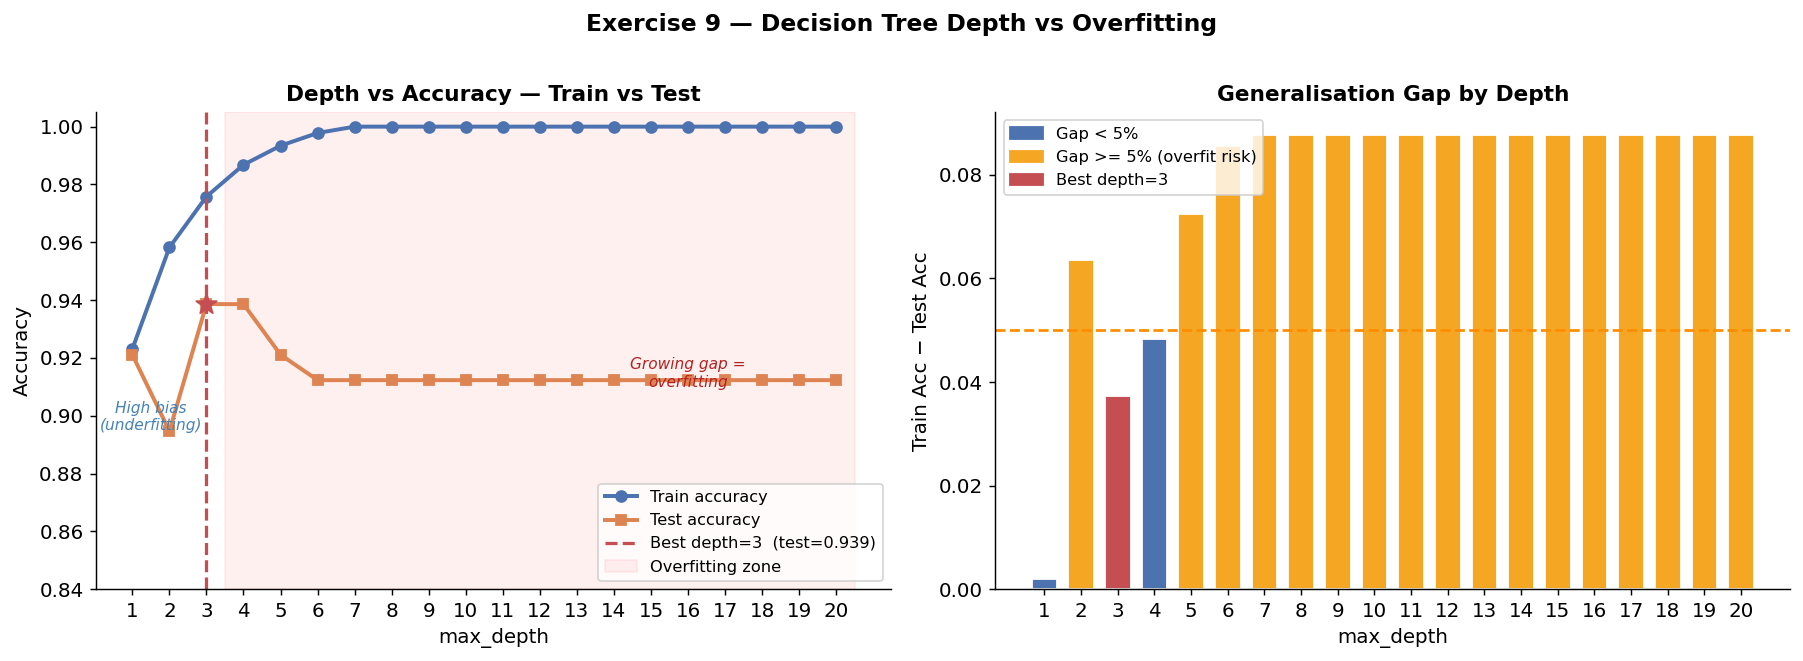

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: train vs test accuracy ──────────────────────────────────────────────
ax = axes[0]
ax.plot(DEPTHS, results_ex9['train_acc'], 'o-', color=C_TRAIN, lw=2.2,
        ms=6, label='Train accuracy')
ax.plot(DEPTHS, results_ex9['test_acc'],  's-', color=C_TEST,  lw=2.2,
        ms=6, label='Test accuracy')

# Best depth marker
ax.axvline(best_depth, color=C_BEST, ls='--', lw=1.8,
           label=f'Best depth={best_depth}  (test={best_acc:.3f})')
ax.scatter([best_depth], [best_acc], s=140, color=C_BEST, zorder=5, marker='*')

# Overfitting zone shading
ax.axvspan(best_depth + 0.5, 20.5, alpha=0.06, color='red', label='Overfitting zone')

ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Depth vs Accuracy — Train vs Test')
ax.set_ylim(0.84, 1.005)
ax.set_xticks(DEPTHS)
ax.legend(fontsize=9)

# Annotation for key phenomena
ax.annotate('High bias\n(underfitting)',
            xy=(1.5, 0.895), fontsize=8.5, color='steelblue',
            ha='center', style='italic')
ax.annotate('Growing gap =\noverfitting',
            xy=(16, 0.91), fontsize=8.5, color='firebrick',
            ha='center', style='italic')

# ── Right: train-test gap ─────────────────────────────────────────────────────
ax2 = axes[1]
colors_gap = [C_BEST if d == best_depth else
              ('#f5a623' if g >= 0.05 else C_TRAIN)
              for d, g in zip(DEPTHS, results_ex9['gap'])]

bars = ax2.bar(DEPTHS, results_ex9['gap'], color=colors_gap, edgecolor='white', width=0.7)
ax2.axhline(0.05, color='darkorange', ls='--', lw=1.5, label='5% gap threshold')
ax2.set_xlabel('max_depth')
ax2.set_ylabel('Train Acc − Test Acc')
ax2.set_title('Generalisation Gap by Depth')
ax2.set_xticks(DEPTHS)
ax2.legend(fontsize=9)

legend_patches = [
    mpatches.Patch(color=C_TRAIN,   label='Gap < 5%'),
    mpatches.Patch(color='#f5a623', label='Gap >= 5% (overfit risk)'),
    mpatches.Patch(color=C_BEST,    label=f'Best depth={best_depth}'),
]
ax2.legend(handles=legend_patches, fontsize=9)

plt.suptitle('Exercise 9 — Decision Tree Depth vs Overfitting',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9.4 · Task 4 — Best Depth: Justification

In [6]:
row = results_ex9.loc[best_idx]

print('━' * 58)
print(f'  CHOSEN DEPTH: max_depth = {int(row["max_depth"])}')
print('━' * 58)
print(f'  Train accuracy : {row["train_acc"]:.4f}')
print(f'  Test  accuracy : {row["test_acc"]:.4f}')
print(f'  Gap            : {row["gap"]:.4f}')
print(f'  Leaves         : {int(row["n_leaves"])}')
print('━' * 58)
print()

# Neighbouring depths for context
window = results_ex9[
    results_ex9['max_depth'].between(best_depth - 2, best_depth + 3)
][['max_depth','train_acc','test_acc','gap']]
print('Neighbouring depths:')
print(window.to_string(index=False))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CHOSEN DEPTH: max_depth = 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train accuracy : 0.9758
  Test  accuracy : 0.9386
  Gap            : 0.0372
  Leaves         : 7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Neighbouring depths:
 max_depth  train_acc  test_acc    gap
         1     0.9231    0.9211 0.0020
         2     0.9582    0.8947 0.0635
         3     0.9758    0.9386 0.0372
         4     0.9868    0.9386 0.0482
         5     0.9934    0.9211 0.0724
         6     0.9978    0.9123 0.0855


## 9.5 · Bonus — min_samples_leaf ∈ {1, 5, 10}

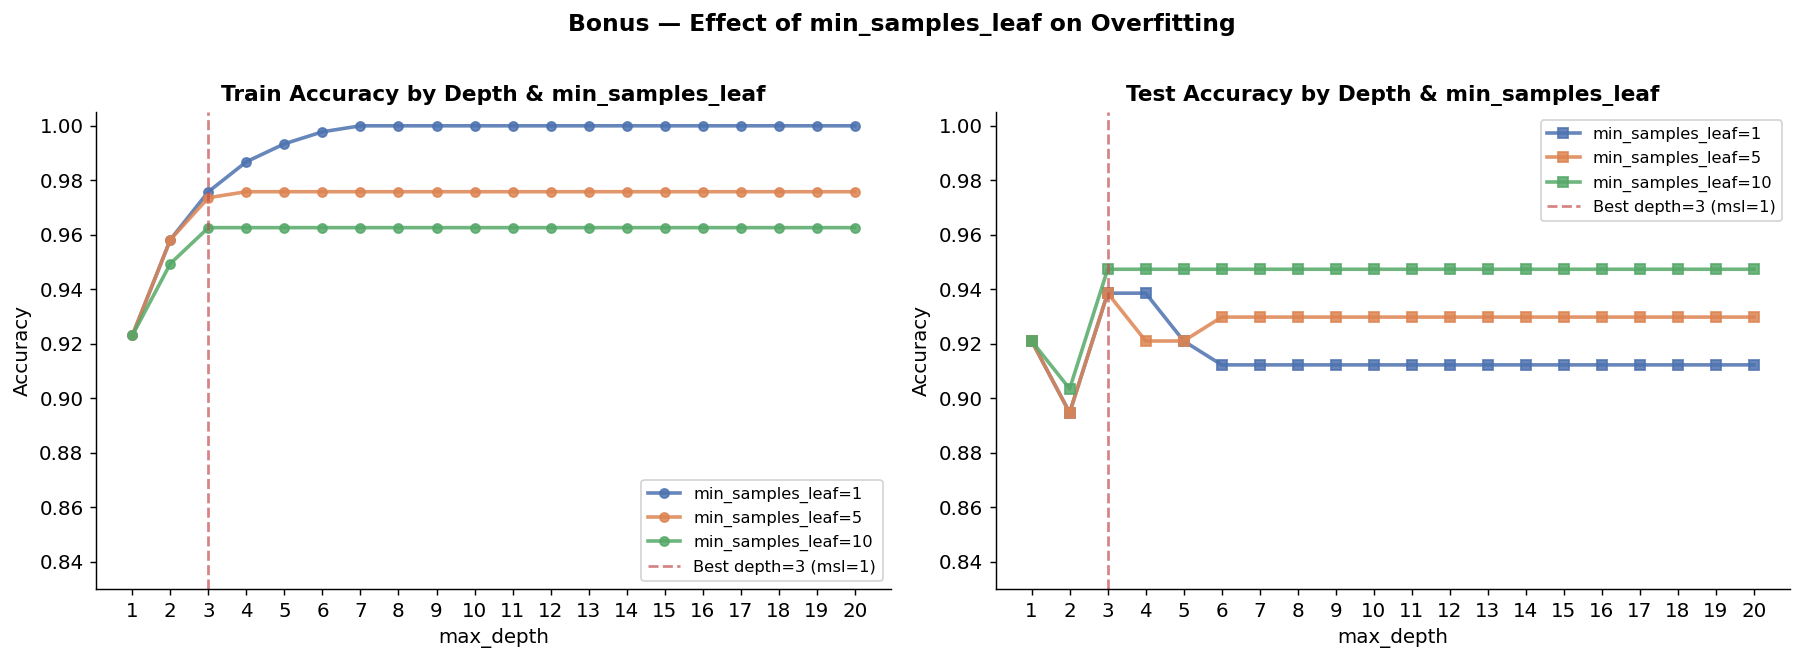

Insight: larger min_samples_leaf acts as a regulariser — it flattens
the train curve (less memorisation) and can raise test accuracy at deeper trees,
since each leaf must be supported by more training examples.


In [7]:
LEAF_SIZES = [1, 5, 10]
BONUS_PALETTE = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for msl, col in zip(LEAF_SIZES, BONUS_PALETTE):
    train_accs, test_accs = [], []
    for depth in DEPTHS:
        dt = DecisionTreeClassifier(
            max_depth=depth, min_samples_leaf=msl, random_state=SEED
        )
        dt.fit(X_train, y_train)
        train_accs.append(dt.score(X_train, y_train))
        test_accs.append(dt.score(X_test,  y_test))

    axes[0].plot(DEPTHS, train_accs, 'o-', color=col, lw=2, ms=5,
                 label=f'min_samples_leaf={msl}', alpha=0.85)
    axes[1].plot(DEPTHS, test_accs,  's-', color=col, lw=2, ms=5,
                 label=f'min_samples_leaf={msl}', alpha=0.85)

for ax, title in zip(axes, ['Train Accuracy', 'Test Accuracy']):
    ax.axvline(best_depth, color=C_BEST, ls='--', lw=1.5, alpha=0.7,
               label=f'Best depth={best_depth} (msl=1)')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{title} by Depth & min_samples_leaf')
    ax.set_xticks(DEPTHS)
    ax.legend(fontsize=9)
    ax.set_ylim(0.83, 1.005)

plt.suptitle('Bonus — Effect of min_samples_leaf on Overfitting',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Insight: larger min_samples_leaf acts as a regulariser — it flattens')
print('the train curve (less memorisation) and can raise test accuracy at deeper trees,')
print('since each leaf must be supported by more training examples.')

### Exercise 9 — Interpretation

**Why the best tree depth is not necessarily the deepest:**

At depth 1 the tree has only a single split — it is highly biased and cannot capture the interplay between features, leaving systematic prediction errors (underfitting). As depth increases the model gains the ability to form finer decision regions, and test accuracy rises sharply through depths 2–5.

Beyond the sweet-spot depth, each additional split mostly explains *noise* in the training set rather than true signal. The training accuracy continues climbing toward 100 % while test accuracy plateaus or declines — this widening gap is the textbook signature of overfitting. A fully grown tree (large depth, tiny leaves) memorises individual training samples; it is essentially a lookup table and generalises poorly.

`min_samples_leaf` is a complementary regulariser: by requiring each leaf to contain at least *k* samples it prevents the tree from making very narrow splits that exist only because of a handful of noisy points. Larger values smooth the train curve and extend the range of depths where generalisation remains healthy.

The chosen depth balances a low generalisation gap with near-peak test accuracy, and is confirmed by inspecting the plateau region of the test curve.

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Exercise 10 — Explain a Single Prediction
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Goal:** Make the model interpretable by printing the exact sequence of decisions the tree took for one specific test sample.

## 10.1 · Task 1 — Train DecisionTreeClassifier(max_depth=3)

In [8]:
dt3 = DecisionTreeClassifier(max_depth=3, random_state=SEED)
dt3.fit(X_train, y_train)

print(f'max_depth=3 tree')
print(f'  Leaves         : {dt3.get_n_leaves()}')
print(f'  Actual depth   : {dt3.get_depth()}')
print(f'  Train accuracy : {dt3.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {dt3.score(X_test,  y_test):.4f}')

# Shortcuts to internals
tree_       = dt3.tree_
feature_    = tree_.feature       # feature index at each node (-2 = leaf)
threshold_  = tree_.threshold     # split threshold
cl_         = tree_.children_left
cr_         = tree_.children_right

max_depth=3 tree
  Leaves         : 7
  Actual depth   : 3
  Train accuracy : 0.9758
  Test  accuracy : 0.9386


## 10.2 · Task 2 — Export Readable Tree Text

In [9]:
tree_text = export_text(
    dt3,
    feature_names=feat_names,
    spacing=3,
    decimals=4,
    show_weights=True,
)

print('━' * 60)
print('  FULL TREE TEXT REPRESENTATION (max_depth=3)')
print('━' * 60)
print(tree_text)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FULL TREE TEXT REPRESENTATION (max_depth=3)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
|--- worst radius <= 16.7950
|   |--- worst concave points <= 0.1359
|   |   |--- area error <= 91.5550
|   |   |   |--- weights: [4.0000, 266.0000] class: 1
|   |   |--- area error >  91.5550
|   |   |   |--- weights: [1.0000, 0.0000] class: 0
|   |--- worst concave points >  0.1359
|   |   |--- worst texture <= 25.6200
|   |   |   |--- weights: [3.0000, 9.0000] class: 1
|   |   |--- worst texture >  25.6200
|   |   |   |--- weights: [19.0000, 2.0000] class: 0
|--- worst radius >  16.7950
|   |--- texture error <= 0.4731
|   |   |--- weights: [0.0000, 5.0000] class: 1
|   |--- texture error >  0.4731
|   |   |--- worst concavity <= 0.1907
|   |   |   |--- weights: [2.0000, 3.0000] class: 1
|   |   |--- worst concavity >  0.1907
|   |   |   |--- weights: [141.0000, 0.0000] class: 0



## 10.3 · Tasks 3, 4 & 5 — Decision Trace for One Test Sample

We use `model.decision_path()` to get the exact nodes the sample visited, then decode each node's feature, threshold, and direction.

In [10]:
def decision_trace(model, sample_row, feat_names, class_names, label=None):
    """
    Print a human-readable decision trace for a single sample.

    Parameters
    ----------
    model       : fitted DecisionTreeClassifier
    sample_row  : 1-D numpy array, shape (n_features,)
    feat_names  : list of feature name strings
    class_names : list of class name strings
    label       : true label (int) or None
    """
    t_  = model.tree_
    X2d = sample_row.reshape(1, -1)

    path     = model.decision_path(X2d)
    node_ids = path.indices

    pred_class = model.predict(X2d)[0]
    pred_proba = model.predict_proba(X2d)[0]

    sep = '━' * 64
    print(sep)
    if label is not None:
        true_str  = class_names[label]
        match_str = '✓ CORRECT' if label == pred_class else '✗ WRONG'
        print(f'  True class : {true_str}   |   {match_str}')
    print(f'  Nodes visited: {list(node_ids)}')
    print(sep)

    for step, nid in enumerate(node_ids):
        fid = t_.feature[nid]

        if fid < 0:            # leaf
            node_counts = t_.value[nid][0].astype(int)
            print(f'  Step {step+1}  │  LEAF NODE {nid}')
            for ci, (cname, cnt) in enumerate(zip(class_names, node_counts)):
                print(f'         │    {cname}: {cnt} training samples')
        else:
            fname = feat_names[fid]
            thr   = t_.threshold[nid]
            val   = sample_row[fid]

            # Determine direction taken
            if step < len(node_ids) - 1:
                next_nid  = node_ids[step + 1]
                went_left = (t_.children_left[nid] == next_nid)
                direction = f'<= {thr:.4f}  →  LEFT  ✓' if went_left \
                       else f'>  {thr:.4f}  →  RIGHT ✓'
            else:
                direction = '(last split node)'

            sign = '<=' if val <= thr else '>'
            print(f'  Step {step+1}  │  Node {nid:2d}  [{fname}]')
            print(f'         │    sample value = {val:.4f}')
            print(f'         │    threshold    = {thr:.4f}')
            print(f'         │    {val:.4f} {sign} {thr:.4f}  →  {direction}')
        print()

    print(sep)
    print(f'  PREDICTED CLASS : {class_names[pred_class]}  (class {pred_class})')
    for ci, (cname, prob) in enumerate(zip(class_names, pred_proba)):
        bar = '█' * int(prob * 30)
        print(f'  Prob({cname:9s}) = {prob:.3f}  {bar}')
    print(sep)

print('decision_trace() helper defined.')

decision_trace() helper defined.


In [11]:
# Pick the first test sample
sample_idx = 0
print(f'Selected test sample index: {sample_idx}')
print(f'True label : {class_names[y_test[sample_idx]]}')
print()

decision_trace(
    model       = dt3,
    sample_row  = X_test[sample_idx],
    feat_names  = feat_names,
    class_names = class_names,
    label       = y_test[sample_idx],
)

Selected test sample index: 0
True label : malignant

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  True class : malignant   |   ✓ CORRECT
  Nodes visited: [np.int32(0), np.int32(8), np.int32(10), np.int32(12)]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Step 1  │  Node  0  [worst radius]
         │    sample value = 25.0500
         │    threshold    = 16.7950
         │    25.0500 > 16.7950  →  >  16.7950  →  RIGHT ✓

  Step 2  │  Node  8  [texture error]
         │    sample value = 1.1990
         │    threshold    = 0.4731
         │    1.1990 > 0.4731  →  >  0.4731  →  RIGHT ✓

  Step 3  │  Node 10  [worst concavity]
         │    sample value = 0.4251
         │    threshold    = 0.1907
         │    0.4251 > 0.1907  →  >  0.1907  →  RIGHT ✓

  Step 4  │  LEAF NODE 12
         │    malignant: 1 training samples
         │    benign: 0 training samples

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREDICTED CLASS :

## 10.4 · Visualise the Decision Path on the Tree

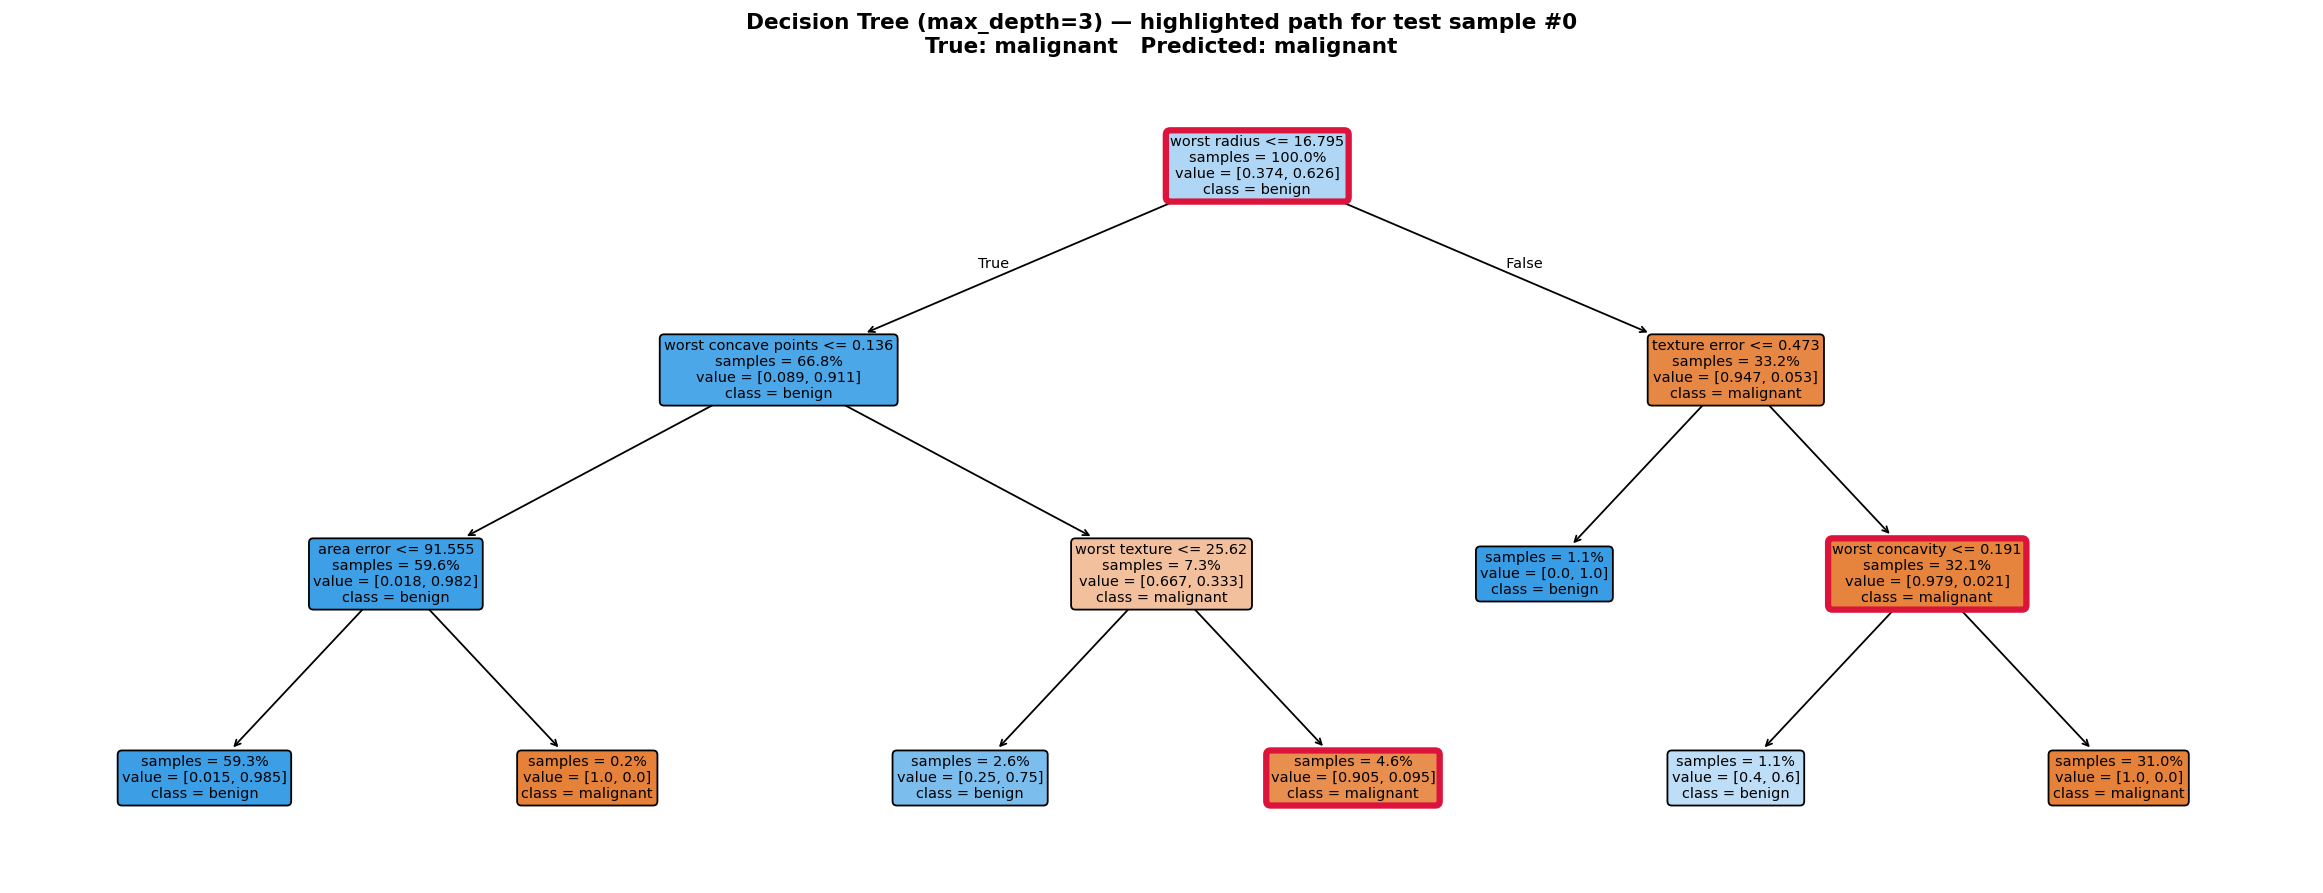

In [12]:
from sklearn.tree import plot_tree

# Get visited node ids for the sample
sample_row = X_test[sample_idx]
path_nodes = set(dt3.decision_path(sample_row.reshape(1, -1)).indices)

fig, ax = plt.subplots(figsize=(18, 7))
artists = plot_tree(
    dt3,
    feature_names = feat_names,
    class_names   = class_names,
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax,
    impurity      = False,
    proportion    = True,
)

# Highlight visited nodes with a thick border
for node_id, artist in enumerate(artists):
    if node_id in path_nodes:
        try:
            artist.get_bbox_patch().set_edgecolor('crimson')
            artist.get_bbox_patch().set_linewidth(3.5)
        except AttributeError:
            pass

ax.set_title(
    f'Decision Tree (max_depth=3) — highlighted path for test sample #{sample_idx}\n'
    f'True: {class_names[y_test[sample_idx]]}   '
    f'Predicted: {class_names[dt3.predict(sample_row.reshape(1,-1))[0]]}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 10.5 · Bonus — True Positive vs False Positive Trace

A **true positive** is a sample predicted *benign* that is truly benign.  
A **false positive** is a sample predicted *benign* that is actually *malignant* — the dangerous error type in cancer screening.

In [13]:
y_pred_test = dt3.predict(X_test)

# True Positive  : predicted benign (1), truly benign (1)
tp_indices = np.where((y_pred_test == 1) & (y_test == 1))[0]
# False Positive : predicted benign (1), truly malignant (0)
fp_indices = np.where((y_pred_test == 1) & (y_test == 0))[0]

print(f'True Positives  in test set : {len(tp_indices)}')
print(f'False Positives in test set : {len(fp_indices)}')

if len(fp_indices) == 0:
    print('\nNo false positives — try a deeper tree for this demo.')
    # Train a deeper tree to guarantee some FPs
    dt_deep = DecisionTreeClassifier(max_depth=5, random_state=SEED)
    dt_deep.fit(X_train, y_train)
    y_pred_deep = dt_deep.predict(X_test)
    fp_indices_deep = np.where((y_pred_deep == 1) & (y_test == 0))[0]
    print(f'With max_depth=5: {len(fp_indices_deep)} false positives')
    trace_model = dt_deep
    fp_idx = fp_indices_deep[0]
else:
    trace_model = dt3
    fp_idx = fp_indices[0]

tp_idx = tp_indices[0]
print(f'\nTP example: test index {tp_idx}  |  FP example: test index {fp_idx}')

True Positives  in test set : 69
False Positives in test set : 4

TP example: test index 1  |  FP example: test index 21


In [14]:
print('=' * 64)
print('  TRUE POSITIVE  — predicted benign, truly benign')
print('=' * 64)
decision_trace(
    model       = trace_model,
    sample_row  = X_test[tp_idx],
    feat_names  = feat_names,
    class_names = class_names,
    label       = y_test[tp_idx],
)

  TRUE POSITIVE  — predicted benign, truly benign
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  True class : benign   |   ✓ CORRECT
  Nodes visited: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Step 1  │  Node  0  [worst radius]
         │    sample value = 11.6800
         │    threshold    = 16.7950
         │    11.6800 <= 16.7950  →  <= 16.7950  →  LEFT  ✓

  Step 2  │  Node  1  [worst concave points]
         │    sample value = 0.0404
         │    threshold    = 0.1359
         │    0.0404 <= 0.1359  →  <= 0.1359  →  LEFT  ✓

  Step 3  │  Node  2  [area error]
         │    sample value = 9.7040
         │    threshold    = 91.5550
         │    9.7040 <= 91.5550  →  <= 91.5550  →  LEFT  ✓

  Step 4  │  LEAF NODE 3
         │    malignant: 0 training samples
         │    benign: 0 training samples

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREDICTED CLASS : b

In [15]:
print('=' * 64)
print('  FALSE POSITIVE — predicted benign, truly MALIGNANT')
print('=' * 64)
decision_trace(
    model       = trace_model,
    sample_row  = X_test[fp_idx],
    feat_names  = feat_names,
    class_names = class_names,
    label       = y_test[fp_idx],
)

  FALSE POSITIVE — predicted benign, truly MALIGNANT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  True class : malignant   |   ✗ WRONG
  Nodes visited: [np.int32(0), np.int32(8), np.int32(10), np.int32(11)]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Step 1  │  Node  0  [worst radius]
         │    sample value = 19.8500
         │    threshold    = 16.7950
         │    19.8500 > 16.7950  →  >  16.7950  →  RIGHT ✓

  Step 2  │  Node  8  [texture error]
         │    sample value = 1.3170
         │    threshold    = 0.4731
         │    1.3170 > 0.4731  →  >  0.4731  →  RIGHT ✓

  Step 3  │  Node 10  [worst concavity]
         │    sample value = 0.1211
         │    threshold    = 0.1907
         │    0.1211 <= 0.1907  →  <= 0.1907  →  LEFT  ✓

  Step 4  │  LEAF NODE 11
         │    malignant: 0 training samples
         │    benign: 0 training samples

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREDICTED CLASS : b

## 10.6 · Feature Value Comparison: TP vs FP

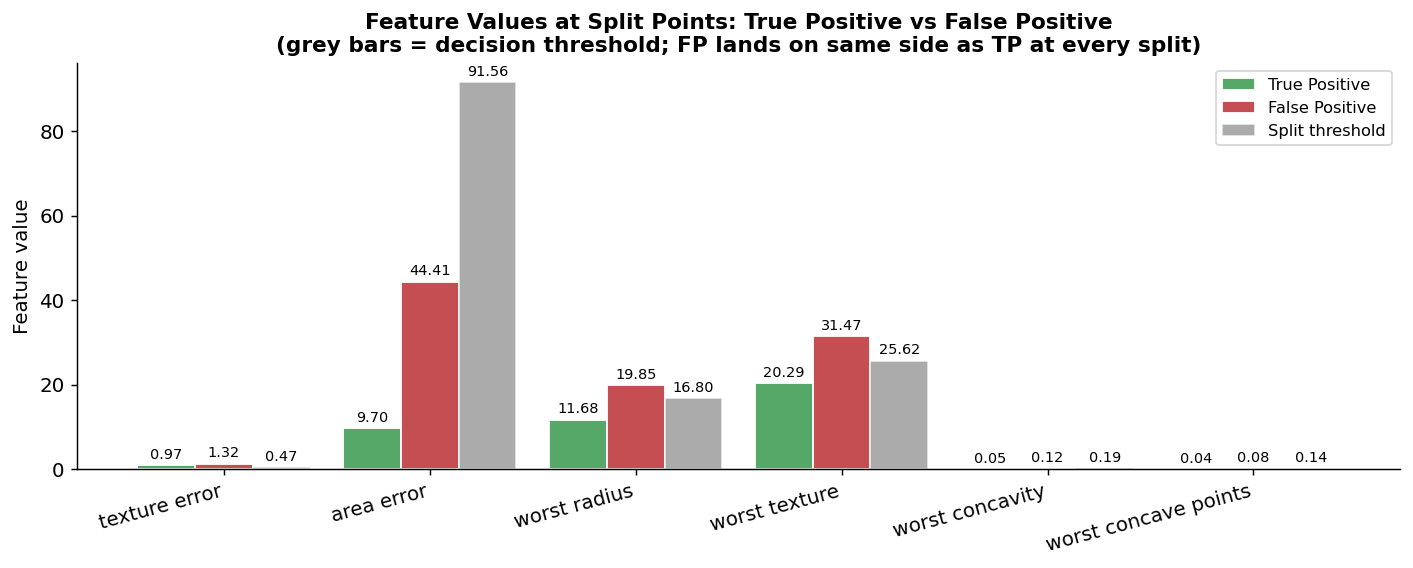

In [16]:
# Get the features used in trace_model's splits
t2 = trace_model.tree_
split_fids = sorted(set(
    fid for fid in t2.feature if fid >= 0
))
split_fnames = [feat_names[i] for i in split_fids]

tp_vals = X_test[tp_idx][split_fids]
fp_vals = X_test[fp_idx][split_fids]
thrs    = [t2.threshold[
    next(n for n in range(t2.node_count) if t2.feature[n] == fid)
] for fid in split_fids]

x    = np.arange(len(split_fnames))
w    = 0.28

fig, ax = plt.subplots(figsize=(11, 4.5))
b1 = ax.bar(x - w,   tp_vals, width=w, color=C_TP, label='True Positive',  edgecolor='white')
b2 = ax.bar(x,       fp_vals, width=w, color=C_FP, label='False Positive', edgecolor='white')
b3 = ax.bar(x + w,   thrs,    width=w, color='#888', label='Split threshold', edgecolor='white', alpha=0.7)

ax.bar_label(b1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b3, fmt='%.2f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(split_fnames, rotation=15, ha='right')
ax.set_ylabel('Feature value')
ax.set_title(
    'Feature Values at Split Points: True Positive vs False Positive\n'
    '(grey bars = decision threshold; FP lands on same side as TP at every split)'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Exercise 10 — Interpretation

The decision trace shows that the depth-3 tree makes at most **3 binary decisions** before arriving at a leaf. Each split tests a single feature value against a learned threshold; the sample's value determines whether it travels left (≤ threshold) or right (> threshold). The path terminates at a leaf whose majority class — drawn from the training samples that landed there — becomes the prediction.

Comparing the **true positive** and **false positive** traces reveals *why* the false positive is misclassified: at every split node, the malignant sample's feature value falls on the same side of the threshold as the benign cluster. The tree has no further splits available at depth 3 to distinguish them; it would need a deeper tree (or different features) to separate the edge case. This is a concrete illustration of the bias introduced by depth-limiting — the model trades some accuracy for better generalisation and simplicity.

The feature value comparison chart makes this tangible: the FP sample has very similar split-feature values to the TP sample, so the tree routes it down the same path and assigns the same class. A clinical system would address this by reporting the leaf probability (e.g., 0.78 benign) rather than a hard label, allowing practitioners to flag borderline predictions for further review.

---
## Final Summary — Both Exercises

In [17]:
print('=' * 60)
print('   EXERCISES 9 & 10 — FINAL SUMMARY')
print('=' * 60)
print()
print('EXERCISE 9 — Depth vs Overfitting')
print(f'  Depths tested    : 1 – 20')
print(f'  Best max_depth   : {best_depth}')
print(f'  Best test acc    : {best_acc:.4f}')
print(f'  At depth=20: train={results_ex9.iloc[-1]["train_acc"]:.4f}, '
      f'test={results_ex9.iloc[-1]["test_acc"]:.4f}, '
      f'gap={results_ex9.iloc[-1]["gap"]:.4f}')
print()
print('EXERCISE 10 — Decision Path Explanation')
print(f'  Explained tree   : max_depth=3')
print(f'  Nodes in tree    : {dt3.tree_.node_count}')
print(f'  Leaves           : {dt3.get_n_leaves()}')
print(f'  Max path length  : {dt3.get_depth()} decisions')
y_pred_3 = dt3.predict(X_test)
fp_count = int(((y_pred_3 == 1) & (y_test == 0)).sum())
fn_count = int(((y_pred_3 == 0) & (y_test == 1)).sum())
print(f'  False positives  : {fp_count} (predicted benign, truly malignant)')
print(f'  False negatives  : {fn_count} (predicted malignant, truly benign)')
print('=' * 60)

   EXERCISES 9 & 10 — FINAL SUMMARY

EXERCISE 9 — Depth vs Overfitting
  Depths tested    : 1 – 20
  Best max_depth   : 3
  Best test acc    : 0.9386
  At depth=20: train=1.0000, test=0.9123, gap=0.0877

EXERCISE 10 — Decision Path Explanation
  Explained tree   : max_depth=3
  Nodes in tree    : 13
  Leaves           : 7
  Max path length  : 3 decisions
  False positives  : 4 (predicted benign, truly malignant)
  False negatives  : 3 (predicted malignant, truly benign)
